In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df=pd.read_csv("test.csv")
df.head()

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Dependents,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price
0,C-26247,Tandra Olszewski,F,47,3472.69,Low,Commercial associate,Managers,Semi-Urban,137088.98,...,2.0,799.14,0,Unpossessed,843,3472.69,2,Urban,1,236644.5
1,C-35067,Jeannette Cha,F,57,1184.84,Low,Working,Sales staff,Rural,104771.59,...,2.0,833.31,0,Unpossessed,22,1184.84,1,Rural,1,142357.3
2,C-34590,Keva Godfrey,F,52,1266.27,Low,Working,NaN,Semi-Urban,176684.91,...,3.0,627.44,0,Unpossessed,1,1266.27,1,Urban,1,300991.24
3,C-16668,Elva Sackett,M,65,1369.72,High,Pensioner,NaN,Rural,97009.18,...,2.0,833.20,0,Inactive,730,1369.72,1,Semi-Urban,0,125612.1
4,C-12196,Sade Constable,F,60,1939.23,High,Pensioner,NaN,Urban,109980.00,...,NaN,NaN,0,NaN,356,1939.23,4,Semi-Urban,1,180908.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  20000 non-null  object 
 1   Name                         20000 non-null  object 
 2   Gender                       19969 non-null  object 
 3   Age                          20000 non-null  int64  
 4   Income (USD)                 19250 non-null  float64
 5   Income Stability             19187 non-null  object 
 6   Profession                   20000 non-null  object 
 7   Type of Employment           15311 non-null  object 
 8   Location                     20000 non-null  object 
 9   Loan Amount Request (USD)    20000 non-null  float64
 10  Current Loan Expenses (USD)  19917 non-null  float64
 11  Expense Type 1               20000 non-null  object 
 12  Expense Type 2               20000 non-null  object 
 13  Dependents      

In [6]:
#Features = X , Target=y

X=df.drop("Loan Amount Request (USD)", axis=1)
y=df["Loan Amount Request (USD)"]

Splitting the Numerical and Categorical Features

In [7]:
numerical_features=X.select_dtypes(include=["int64", "float64"]).columns
categorical_features=X.select_dtypes(include=["object"]).columns

Data Preprocessing

* Handle Missing
* Encode Categorical Data
* Standardize Numerical Features

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Exploratory Data Analysis (EDA)

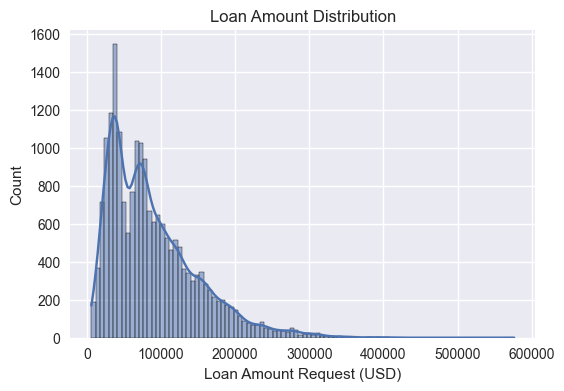

In [14]:
# Target Distribution

plt.figure(figsize=(6,4))
sns.histplot(y, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

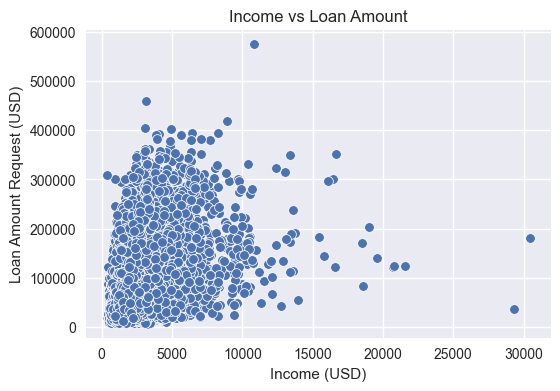

In [16]:
# Feature vs Target (Example: Income)

plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Income (USD)"],y=y)
plt.title("Income vs Loan Amount")
plt.show()

Baseline Linear Regression

In [20]:
linear_model=Pipeline(steps=[("preprocessor",preprocessor),("model", LinearRegression())])

start=time.time()
linear_model.fit(X_train, y_train)
train_time_linear=time.time()-start

print("Training Time is",train_time_linear)

Training Time is 0.31002330780029297


In [22]:
y_pred=linear_model.predict(X_test)

mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)


print("Linear Regression Performance")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("Training Time:", train_time_linear)


Linear Regression Performance
MAE: 27677.626088417375
MSE: 1477164691.227131
RMSE: 38433.90028642853
R2: 0.5915858847239857
Training Time: 0.31002330780029297


The baseline Linear Regression model achieved an R² score of 0.59, indicating moderate predictive capability. While errors are relatively high due to the complexity of real-world financial data, the model provides a strong reference for evaluating regularized models.

Ridge Regression (with Grid Search)

In [26]:
ridge=Pipeline(steps=[("preprocessor",preprocessor),("model",Ridge())])

param_grid_ridge={"model__alpha": [0.01,0.1,1,10,100]}

ridge_search=GridSearchCV(ridge,param_grid_ridge,cv=5,scoring="r2", return_train_score=True)

ridge_search.fit(X_train,y_train)

,estimator,"Pipeline(step...l', Ridge())])"
,param_grid,"{'model__alpha': [0.01, 0.1, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [1]:
ridge_search.best_params_

NameError: name 'ridge_search' is not defined

alpha = 100

Dataset benefits from strong regularization
* Features are likely correlated
* Linear Regression was slightly overfitting
* Shrinking coefficients improves generalization

In [28]:
ridge_search.best_score_
best_ridge = ridge_search.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_ridge)

Ridge R2: 0.5918445761848306


GridSearchCV with 5-fold cross-validation is used to select the optimal regularization parameter alpha.
The best_ridge model is the Ridge Regression pipeline retrained on the full training dataset using the best alpha value (100).

Lasso Regression

In [29]:
lasso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=5000))
])

param_grid_lasso = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_search = GridSearchCV(
    lasso,
    param_grid_lasso,
    cv=5,
    scoring="r2"
)

lasso_search.fit(X_train, y_train)

In [ ]:
lasso_search.best_params_

In [ ]:
best_lasso = lasso_search.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Performance")
print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)

Elastic Net Regression

In [ ]:
elastic = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(max_iter=5000))
])

param_grid_elastic = {
    "model__alpha": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

elastic_search = GridSearchCV(
    elastic,
    param_grid_elastic,
    cv=5,
    scoring="r2"
)

elastic_search.fit(X_train, y_train)


In [ ]:
elastic_search.best_params_

In [ ]:
best_elastic = elastic_search.best_estimator_
y_pred_elastic = best_elastic.predict(X_test)

mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)

print("Elastic Net Regression Performance")
print("MAE:", mae_elastic)
print("MSE:", mse_elastic)
print("RMSE:", rmse_elastic)
print("R2:", r2_elastic)


In [ ]:
# Baseline Linear Plot

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Predicted vs Actual")
plt.show()


In [ ]:
# Ridge Plot

y_pred_ridge = best_ridge.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Predicted vs Actual – Ridge Regression")
plt.show()


In [ ]:
# Lasso Plot

y_pred_lasso = best_lasso.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Predicted vs Actual – Lasso Regression")
plt.show()

In [ ]:
# Elastic Net Plot

y_pred_elastic = best_elastic.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Predicted vs Actual – Elastic Net Regression")
plt.show()

Residual Plot

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red")
plt.title("Residual Plot")
plt.show()

Training Error vs Validation Error Plot (for ridge)

This plot answers:
* If my model is overfitting?
* Does regularization reduce variance?

In [ ]:
results = ridge_search.cv_results_

alphas = results["param_model__alpha"].data
train_scores = results["mean_train_score"]
val_scores = results["mean_test_score"]

train_error = 1 - train_scores
val_error = 1 - val_scores

plt.figure(figsize=(6,4))
plt.plot(alphas, train_error, marker='o', label="Training Error")
plt.plot(alphas, val_error, marker='o', label="Validation Error")
plt.xscale("log")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Error (1 - R²)")
plt.title("Training vs Validation Error – Ridge Regression")
plt.legend()
plt.show()

Coefficient Comparison Bar Plot

(How regularizaition affects feature importance)

feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

coef_linear = linear_model.named_steps["model"].coef_
coef_ridge = best_ridge.named_steps["model"].coef_
coef_lasso = best_lasso.named_steps["model"].coef_
coef_elastic = best_elastic.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear": coef_linear,
    "Ridge": coef_ridge,
    "Lasso": coef_lasso,
    "ElasticNet": coef_elastic
})

coef_df.head()

In [ ]:
top_features = coef_df.reindex(
    coef_df["Linear"].abs().sort_values(ascending=False).head(10).index
)

top_features.set_index("Feature").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Coefficient Comparison Across Models")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()